## Préparer l'environnement pour utiliser `src`

Avant d'utiliser nos scripts Python dans `src`, il faut que Python sache où les trouver.  
Cette cellule fait deux choses :

1. Ajoute le dossier `src` au **Python PATH** pour que les imports fonctionnent, même si le notebook est dans `notebooks/`.
2. Importe les fonctions clés :
   - `load_data` et `encode_features` depuis `preprocessing.py`
   - `train_model` depuis `model.py`
   - `evaluate_model` depuis `evaluation.py`

On imprime aussi `sys.path` pour vérifier que Python voit bien le dossier `src`.

In [22]:
import sys
import os

# Ajouter le dossier parent au PATH
sys.path.append(os.path.abspath('../src'))
# Ajouter le chemin absolu vers le dossier src
sys.path.append(os.path.abspath('../src'))

# Vérifie que Python voit le dossier
print(sys.path)

# Maintenant les imports fonctionnent
from preprocessing import load_data, encode_features
from model import train_model
from evaluation import evaluate_model

['c:\\Users\\DELL\\anaconda3\\python313.zip', 'c:\\Users\\DELL\\anaconda3\\DLLs', 'c:\\Users\\DELL\\anaconda3\\Lib', 'c:\\Users\\DELL\\anaconda3', '', 'C:\\Users\\DELL\\AppData\\Roaming\\Python\\Python313\\site-packages', 'C:\\Users\\DELL\\AppData\\Roaming\\Python\\Python313\\site-packages\\win32', 'C:\\Users\\DELL\\AppData\\Roaming\\Python\\Python313\\site-packages\\win32\\lib', 'C:\\Users\\DELL\\AppData\\Roaming\\Python\\Python313\\site-packages\\Pythonwin', 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages', 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\win32', 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\Pythonwin', 'c:\\Users\\DELL\\anaconda3\\Lib\\site-packages\\setuptools\\_vendor', 'c:\\Users\\DELL\\OneDrive\\Desktop\\Projet S2\\Machine Learning\\ML-HealthCare-Projects\\src', 'c:\\Users\\DELL\\OneDrive\\Desktop\\Projet S2\\Machine Learning\\ML-HealthCare-Projects\\src']


## Projet : Prédiction des Charges Médicales
Ce projet vise à prédire les charges médicales individuelles aux États-Unis en fonction de caractéristiques personnelles comme l'âge, le sexe, l'IMC, le nombre d'enfants, le statut fumeur et la région.

In [ ]:
import pandas as pd

df = pd.read_csv("../data/medical-charges.csv")
df.head()
df.tail()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Chargement du dataset
### Analyse Univariée
Histogrammes et boxplots pour les variables numériques
### Analyse des variables catégorielles

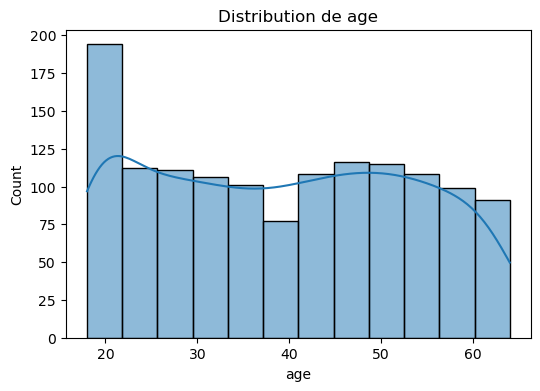

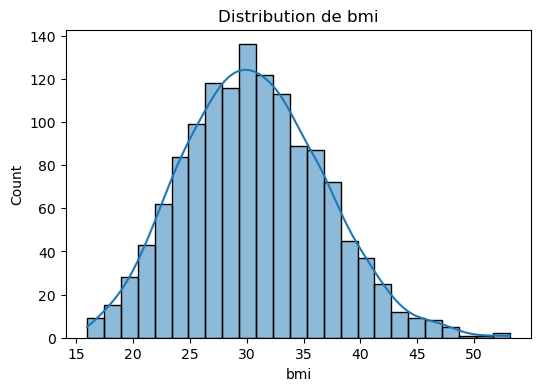

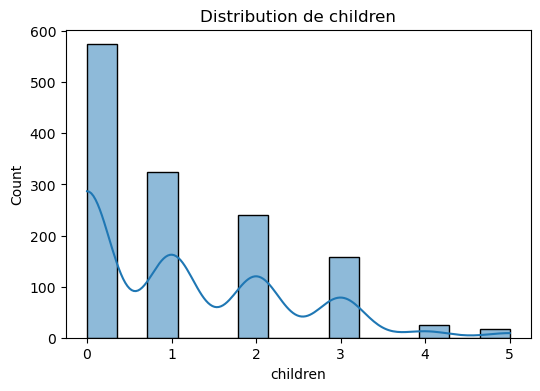

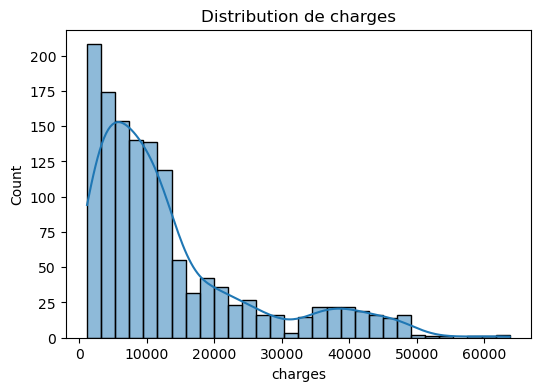

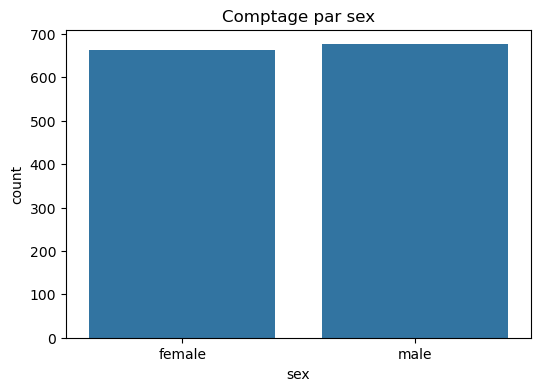

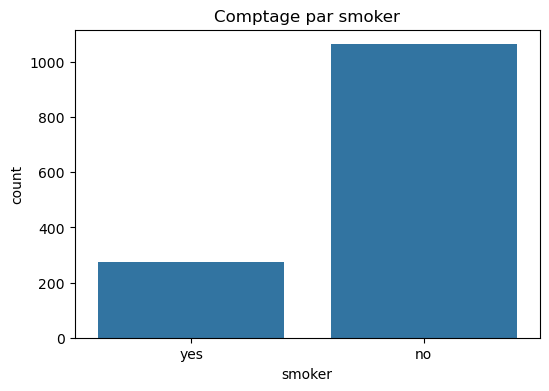

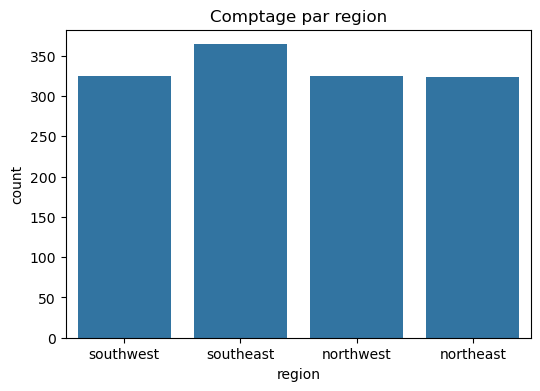

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogrammes pour variables numériques
num_cols = ['age', 'bmi', 'children', 'charges']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution de {col}')
    plt.show()

# Countplots pour variables catégorielles
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f'Comptage par {col}')
    plt.show()

Visualisation des relations entre features et charges

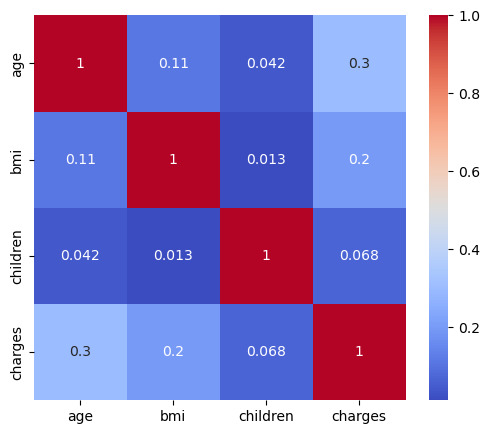

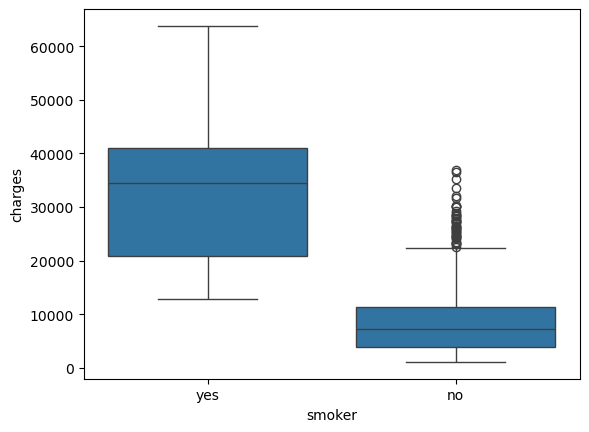

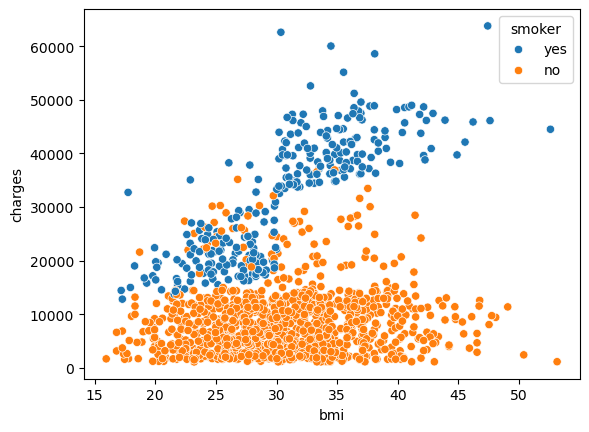

In [6]:
# Corrélation
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

# Charges vs smoker
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

# Scatter BMI vs charges coloré par fumeur
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.show()

###  Gestion des valeurs manquantes et doublons

In [8]:
df.isnull().sum()
df.duplicated().sum()

np.int64(1)

### Encodage des variables catégorielles

In [9]:
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [8]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("../data/medical-charges.csv")
df.head()
scaler = StandardScaler()
scaled_cols = ['age', 'bmi', 'children']
df[scaled_cols] = scaler.fit_transform(df[scaled_cols])

###  Feature Scaling et Train/Test Split

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression

In [19]:
# 1) Imports 
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 2) Load dataset
df = pd.read_csv("../data/medical-charges.csv")

# 3) Encoding categorical variables
df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

# 4) Split features and target
X = df.drop('charges', axis=1)
y = df['charges']

# 5) Train / Test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 6) Scaling numerical columns

scaler = StandardScaler()
scaled_cols = ['age', 'bmi', 'children']

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.transform(X_test[scaled_cols])

# 7) Train models

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

# 8) Evaluate models

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")


Linear Regression
RMSE: 5796.28
MAE: 4181.19
R²: 0.7836

Ridge
RMSE: 5800.46
MAE: 4193.20
R²: 0.7833

Lasso
RMSE: 5796.36
MAE: 4181.30
R²: 0.7836

ElasticNet
RMSE: 6367.48
MAE: 4788.17
R²: 0.7388


In [14]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import cross_val_score

models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} R²: {model.score(X_test, y_test):.3f}")

Linear R²: 0.784
Ridge R²: 0.783
Lasso R²: 0.784
ElasticNet R²: 0.739


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def eval_model(y_true, y_pred, n_features):
    n = len(y_true)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = np.corrcoef(y_true, y_pred)[0,1]**2
    r2_adj = 1 - (1-r2)*(n-1)/(n-n_features-1)
    return rmse, mae, r2, r2_adj

for name, model in models.items():
    y_pred = model.predict(X_test)
    rmse, mae, r2, r2_adj = eval_model(y_test, y_pred, X_train.shape[1])
    print(f"{name}: RMSE={rmse:.2f}, MAE={mae:.2f}, R²={r2:.3f}, R²_adj={r2_adj:.3f}")

Linear: RMSE=5796.28, MAE=4181.19, R²=0.784, R²_adj=0.778
Ridge: RMSE=5800.46, MAE=4193.20, R²=0.784, R²_adj=0.778
Lasso: RMSE=5796.36, MAE=4181.30, R²=0.784, R²_adj=0.778
ElasticNet: RMSE=6367.48, MAE=4788.17, R²=0.775, R²_adj=0.768


In [16]:
X_train.dtypes

age                 float64
bmi                 float64
children            float64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

## — Sélection de Features : Backward Elimination

L'objectif est de supprimer les features non significatives dans notre modèle de régression linéaire.
Nous utilisons `statsmodels` pour obtenir les p-values et retirer itérativement les features dont la p-value > 0.05.
Les features conservées sont celles qui contribuent significativement à la prédiction des charges médicales.

In [17]:
# Convertir les colonnes booléennes en int
X_train_sm = X_train.copy()
bool_cols = X_train_sm.select_dtypes(include='bool').columns
X_train_sm[bool_cols] = X_train_sm[bool_cols].astype(int)

# Ajouter la constante
import statsmodels.api as sm
X_train_sm = sm.add_constant(X_train_sm)

# Lancer OLS
model_sm = sm.OLS(y_train, X_train_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     380.9
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.32e-305
Time:                        22:37:50   Log-Likelihood:                -10845.
No. Observations:                1070   AIC:                         2.171e+04
Df Residuals:                    1061   BIC:                         2.175e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8955.2448    434.334  

### Résultats et Interprétation

Après la Backward Elimination, les features conservées sont :
- `age`
- `bmi`
- `children`
- `smoker_yes`

Ces variables sont significatives pour la prédiction des charges médicales.  
Les autres features (`sex_male`, `region_northwest`, `region_southeast`, `region_southwest`) ont été supprimées car elles n’apportaient pas de valeur prédictive significative (p-value > 0.05).

In [18]:
import statsmodels.api as sm

X_be = X_train_sm.copy()
X_be = sm.add_constant(X_be)

# Backward Elimination
while True:
    model = sm.OLS(y_train, X_be).fit()
    p_values = model.pvalues
    max_p = p_values.max()
    if max_p > 0.05:
        feature_to_remove = p_values.idxmax()
        if feature_to_remove == 'const':
            break
        print(f"Suppression de {feature_to_remove} avec p-value = {max_p}")
        X_be = X_be.drop(columns=[feature_to_remove])
    else:
        break

print("\nFeatures finales retenues :")
print(X_be.columns)
print("\nRésumé du modèle final :")
print(model.summary())

Suppression de sex_male avec p-value = 0.9605914704341609
Suppression de region_northwest avec p-value = 0.4895860820074036
Suppression de region_southeast avec p-value = 0.31283407883130304
Suppression de region_southwest avec p-value = 0.29020657773162195

Features finales retenues :
Index(['const', 'age', 'bmi', 'children', 'smoker_yes'], dtype='object')

Résumé du modèle final :
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     762.1
Date:                Tue, 07 Apr 2026   Prob (F-statistic):          1.26e-310
Time:                        22:37:57   Log-Likelihood:                -10847.
No. Observations:                1070   AIC:                         2.170e+04
Df Residuals:                    1065   BIC:                 